# Section 3: Linear Regression Baselines
## 3.1 Imports and Setup
Import the modeling, preprocessing, diagnostic, and visualization libraries used in the linear-regression workflow.

**Output.** Defines dependencies for the notebook.

In [1]:
from pathlib import Path
Path("plots_overleaf").mkdir(exist_ok=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA


## 3.2 Load Cleaned Data
Load the cleaned dataset generated in Section 1.

**Output.** Shows a preview of the modeling dataset.

In [2]:
df = pd.read_csv("merged_data.csv")
df.head()


,realSum,logSum,room_type_apt,room_type_private,room_type_shared,person_capacity,is_superhost,multi,biz,cleanliness_rating,satisfaction_rating,bedrooms,dist,metro_dist,attr_index,rest_index,city,is_weekday
0,194.033698,5.268032,0,1,0,2.0,0,1,0,10.0,93.0,1,5.022964,2.539380,78.690379,98.253896,Amsterdam,1
1,344.245776,5.841356,0,1,0,4.0,0,0,0,8.0,85.0,1,0.488389,0.239404,631.176378,837.280757,Amsterdam,1
2,264.101422,5.576333,0,1,0,2.0,0,0,1,9.0,87.0,1,5.748312,3.651621,75.275877,95.386955,Amsterdam,1
3,433.529398,6.071960,0,1,0,4.0,0,0,1,9.0,90.0,2,0.384862,0.439876,493.272534,875.033098,Amsterdam,1
4,485.552926,6.185288,0,1,0,2.0,1,0,0,10.0,98.0,1,0.544738,0.318693,552.830324,815.305740,Amsterdam,1


## 3.3 Define Predictors and Target
Separate numeric, binary, city, and target columns for consistent preprocessing.

**Output.** Creates `X` and `y` for the regression models.

In [3]:
# Define predictors and target.

numeric_cols = [
    "cleanliness_rating",
    "satisfaction_rating",
    "person_capacity", 
    "bedrooms", 
    "dist", 
    "metro_dist",
    "attr_index", 
    "rest_index"]

binary_cols = [
    "room_type_apt", 
    "room_type_private",
    "is_superhost", 
    "multi", 
    "biz", 
    "is_weekday"]

categorical_cols = ["city"]

target_col = "logSum"

raw_feature_cols = numeric_cols + binary_cols + categorical_cols

X = df[raw_feature_cols].copy()
y = df[target_col].copy()


## 3.4 Preprocess Features
Standardize continuous predictors, pass binary predictors through unchanged, and encode city fixed effects.

**Output.** Creates a named processed feature matrix.

In [4]:
preprocess = ColumnTransformer(
    transformers=[
        ("scale_numeric", StandardScaler(), numeric_cols),

        ("binary", "passthrough", binary_cols),

        ("city_dummies", OneHotEncoder(
            drop="first", 
            handle_unknown="ignore", 
            sparse_output=False
            ), categorical_cols),
    ],
    remainder="drop",
)

preprocess.fit(X)

city_dummy_cols = list(
    preprocess.named_transformers_["city_dummies"].get_feature_names_out(categorical_cols)
)

all_feature_cols = numeric_cols + binary_cols + city_dummy_cols

X_processed = pd.DataFrame(
    preprocess.transform(X), columns=all_feature_cols, index=X.index,
)


## 3.5 Inspect Processed Features
Confirm that scaling and dummy encoding produced the expected columns.

**Output.** Shows the first rows of `X_processed`.

In [5]:
X_processed.head()


,cleanliness_rating,satisfaction_rating,person_capacity,bedrooms,dist,metro_dist,attr_index,rest_index,room_type_apt,room_type_private,...,is_weekday,city_Athens,city_Barcelona,city_Berlin,city_Budapest,city_Lisbon,city_London,city_Paris,city_Rome,city_Vienna
0,0.640171,0.044027,-0.889287,-0.241320,0.761648,2.155330,-0.956307,-1.058388,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-1.456353,-0.850966,0.659044,-0.241320,-1.129569,-0.515882,1.515708,0.427149,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-0.408091,-0.627218,-0.889287,-0.241320,1.064166,3.447096,-0.971585,-1.064151,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-0.408091,-0.291595,0.659044,1.382141,-1.172747,-0.283052,0.898678,0.503036,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.640171,0.603398,-0.889287,-0.241320,-1.106068,-0.423796,1.165160,0.382976,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 3.6 Naive OLS Baseline
Fit an OLS model without city fixed effects to establish a simple linear baseline.

**Output.** Fits the model and saves residual diagnostic plots.

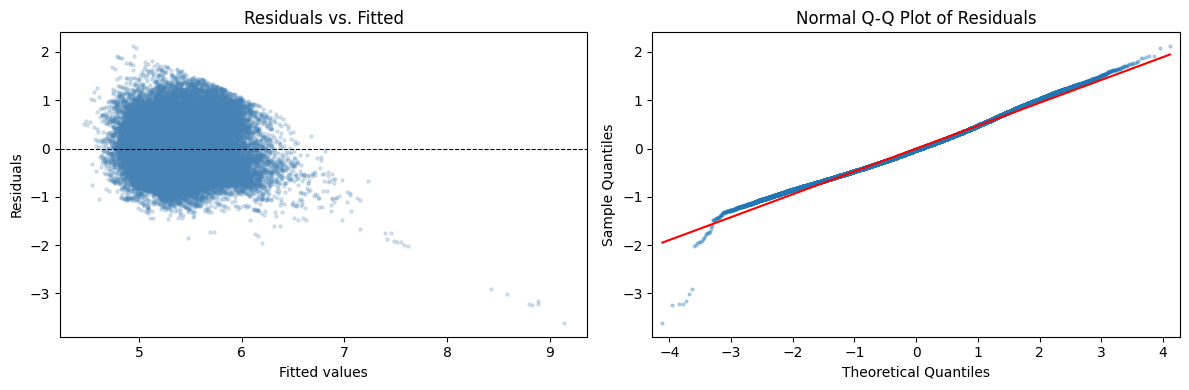

In [6]:

# Exclude city fixed effects; shared room is the room-type reference.

naive_feature_cols = [
    "cleanliness_rating", "satisfaction_rating",
    "person_capacity", "bedrooms", 
    "dist", "metro_dist",
    "attr_index", "rest_index",
    "room_type_apt", "room_type_private",
    "is_superhost", "multi", "biz",
    "is_weekday"
]

X_naive = X_processed[naive_feature_cols].copy()

X_naive_const = sm.add_constant(X_naive)
model_naive = sm.OLS(y, X_naive_const).fit()

vif_data = {
    "Feature": naive_feature_cols,
    "VIF": [variance_inflation_factor(X_naive_const.values, i) for i in range(1, X_naive_const.shape[1])],
}

vif_df = (
    pd.DataFrame(vif_data)
    .sort_values("VIF", ascending=False)
    .reset_index(drop=True)
)

fitted = model_naive.fittedvalues
residuals = model_naive.resid

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(fitted, residuals, alpha=0.2, s=5, color="steelblue")
axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_xlabel("Fitted values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs. Fitted")

sm.qqplot(residuals, line="s", ax=axes[1], alpha=0.3, markersize=2)
axes[1].set_title("Normal Q-Q Plot of Residuals")

plt.tight_layout()
plt.savefig("plots_overleaf/App5_1_NaiveOLSDiagnostics.png", dpi=300, bbox_inches="tight")
plt.show()


## 3.7 Naive OLS Coefficients
Display coefficient estimates and inference statistics for the naive baseline.

**Output.** Shows a coefficient table.

In [7]:
naive_coef_df = model_naive.summary2().tables[1].round(4)
display(naive_coef_df)


,Coef.,Std.Err.,t,P>|t|,[0.025,0.975]
const,4.9420,0.0252,196.1981,0.0000,4.8926,4.9914
cleanliness_rating,0.0144,0.0030,4.7871,0.0000,0.0085,0.0203
satisfaction_rating,-0.0042,0.0031,-1.3737,0.1695,-0.0102,0.0018
person_capacity,0.0569,0.0030,19.2033,0.0000,0.0511,0.0627
bedrooms,0.0846,0.0026,32.7388,0.0000,0.0795,0.0896
dist,0.1101,0.0028,39.7282,0.0000,0.1046,0.1155
metro_dist,-0.0729,0.0025,-28.6791,0.0000,-0.0779,-0.0679
attr_index,0.1850,0.0040,45.7992,0.0000,0.1771,0.1930
rest_index,0.0192,0.0040,4.7556,0.0000,0.0113,0.0271
room_type_apt,0.6212,0.0250,24.8706,0.0000,0.5722,0.6701


## 3.8 Naive OLS Multicollinearity Check
Inspect variance inflation factors for the naive baseline predictors.

**Output.** Displays the VIF table.

In [8]:
display(vif_df)


,Feature,VIF
0,room_type_private,33.707033
1,room_type_apt,33.258775
2,attr_index,3.728831
3,rest_index,3.718185
4,satisfaction_rating,2.151590
5,cleanliness_rating,2.070552
6,person_capacity,2.008166
7,dist,1.753224
8,bedrooms,1.523670
9,metro_dist,1.475180


## 3.9 City Fixed-Effects OLS
Add city fixed effects to control for persistent city-level price differences.

**Output.** Fits the model and saves residual diagnostic plots.

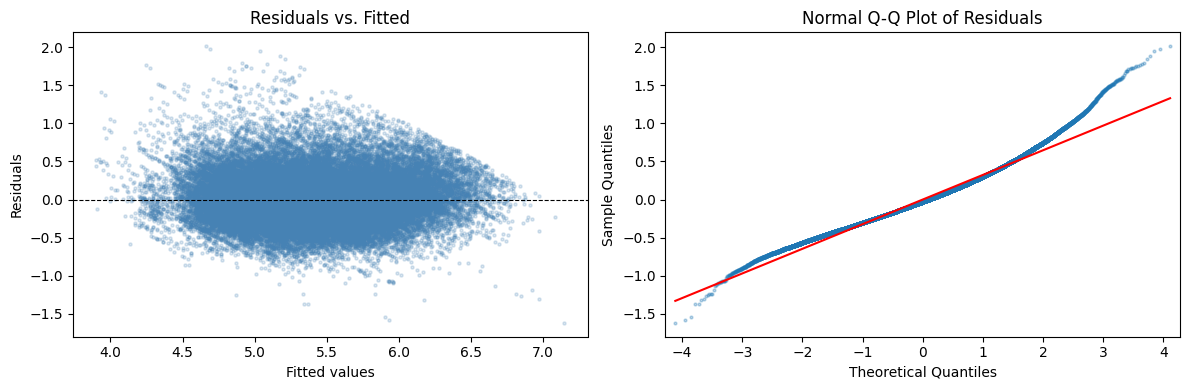

In [9]:

# Amsterdam is the reference city.

X_full_const = sm.add_constant(X_processed)
model_full = sm.OLS(y, X_full_const).fit()

vif_full = pd.DataFrame({
    "Feature": all_feature_cols,
    "VIF": [variance_inflation_factor(X_full_const.values, i) for i in range(1, X_full_const.shape[1])],
}).sort_values("VIF", ascending=False).reset_index(drop=True)

fitted_full = model_full.fittedvalues
residuals_full = model_full.resid

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(fitted_full, residuals_full, alpha=0.2, s=5, color="steelblue")
axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_xlabel("Fitted values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs. Fitted")

sm.qqplot(residuals_full, line="s", ax=axes[1], alpha=0.3, markersize=2)
axes[1].set_title("Normal Q-Q Plot of Residuals")

plt.tight_layout()
plt.savefig("plots_overleaf/App5_1_CityFixedEffectsOLSDiagnostics.png", dpi=300, bbox_inches="tight")
plt.show()


## 3.10 City Fixed-Effects Coefficients
Display coefficient estimates for the city fixed-effects model.

**Output.** Shows a coefficient table.

In [10]:
city_fe_coef_df = model_full.summary2().tables[1].round(4)
display(city_fe_coef_df)


,Coef.,Std.Err.,t,P>|t|,[0.025,0.975]
const,5.5480,0.0188,294.7575,0.0000,5.5111,5.5849
cleanliness_rating,0.0372,0.0021,18.0190,0.0000,0.0331,0.0412
satisfaction_rating,0.0053,0.0021,2.5365,0.0112,0.0012,0.0095
person_capacity,0.1141,0.0020,55.8620,0.0000,0.1101,0.1181
bedrooms,0.0768,0.0018,43.0069,0.0000,0.0733,0.0803
dist,-0.0538,0.0025,-21.5689,0.0000,-0.0587,-0.0489
metro_dist,-0.0169,0.0019,-9.0723,0.0000,-0.0205,-0.0132
attr_index,0.0806,0.0029,28.1624,0.0000,0.0750,0.0862
rest_index,0.0566,0.0033,17.1464,0.0000,0.0501,0.0630
room_type_apt,0.8248,0.0171,48.1577,0.0000,0.7912,0.8584


## 3.11 City Fixed-Effects Multicollinearity Check
Inspect variance inflation factors after adding city indicators.

**Output.** Displays the VIF table.

In [11]:
display(vif_full)


,Feature,VIF
0,room_type_private,33.941027
1,room_type_apt,33.534862
2,city_London,5.982500
3,city_Rome,5.971312
4,rest_index,5.329073
5,city_Paris,4.508016
6,attr_index,4.015537
7,city_Lisbon,3.845803
8,city_Athens,3.650371
9,dist,3.048718


## 3.12 Linear Baseline Comparison
Compare naive OLS and city fixed-effects OLS on fit statistics and model complexity.

**Output.** Displays a model-comparison table.

In [12]:
model_comparison = pd.DataFrame({
    'Metric': ['R²', 'Adj. R²', 'RMSE', 'AIC', 'BIC', 'F-statistic', '# predictors'],
    'Naive OLS': [
        model_naive.rsquared,
        model_naive.rsquared_adj,
        np.sqrt(model_naive.mse_resid),
        model_naive.aic,
        model_naive.bic,
        model_naive.fvalue,
        len(naive_feature_cols),
    ],
    'City FE OLS': [
        model_full.rsquared,
        model_full.rsquared_adj,
        np.sqrt(model_full.mse_resid),
        model_full.aic,
        model_full.bic,
        model_full.fvalue,
        len(all_feature_cols),
    ],
}).set_index('Metric').round(4)

display(model_comparison)


,Naive OLS,City FE OLS
Metric,,
R²,0.2863,0.6672
Adj. R²,0.2861,0.6671
RMSE,0.4734,0.3233
AIC,68720.1485,29680.5136
BIC,68852.7977,29892.7523
F-statistic,1466.3760,4460.4904
# predictors,14.0000,23.0000
